# Analysis Notebook Template   

copy of injection_and_recovery_v2

In [2]:
%run install_packages.py

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, RectangularAperture
from test_analysis import read_in_fits
from analysis_functions import *

## Load data

In [13]:
TRIM_FRAMES = (199,-1)


In [14]:
data = read_in_fits('./data/260203/zenith_sky_1')

Processing 1500 FITS files from ./data/260203/zenith_sky_1
Loaded 1500 FITS files from ./data/260203/zenith_sky_1


In [15]:
# Pick the first image and just preview columns 0 - 20 and all rows to see what the channel looks like 

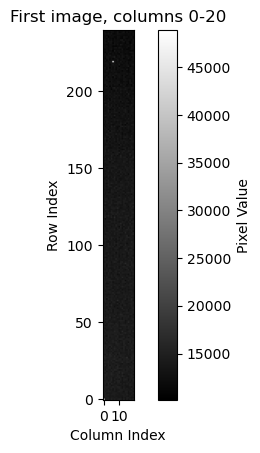

In [16]:
plt.imshow(data[0,:, :20], origin='lower', cmap='gray')
plt.title('First image, columns 0-20')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.colorbar(label='Pixel Value')
plt.show()

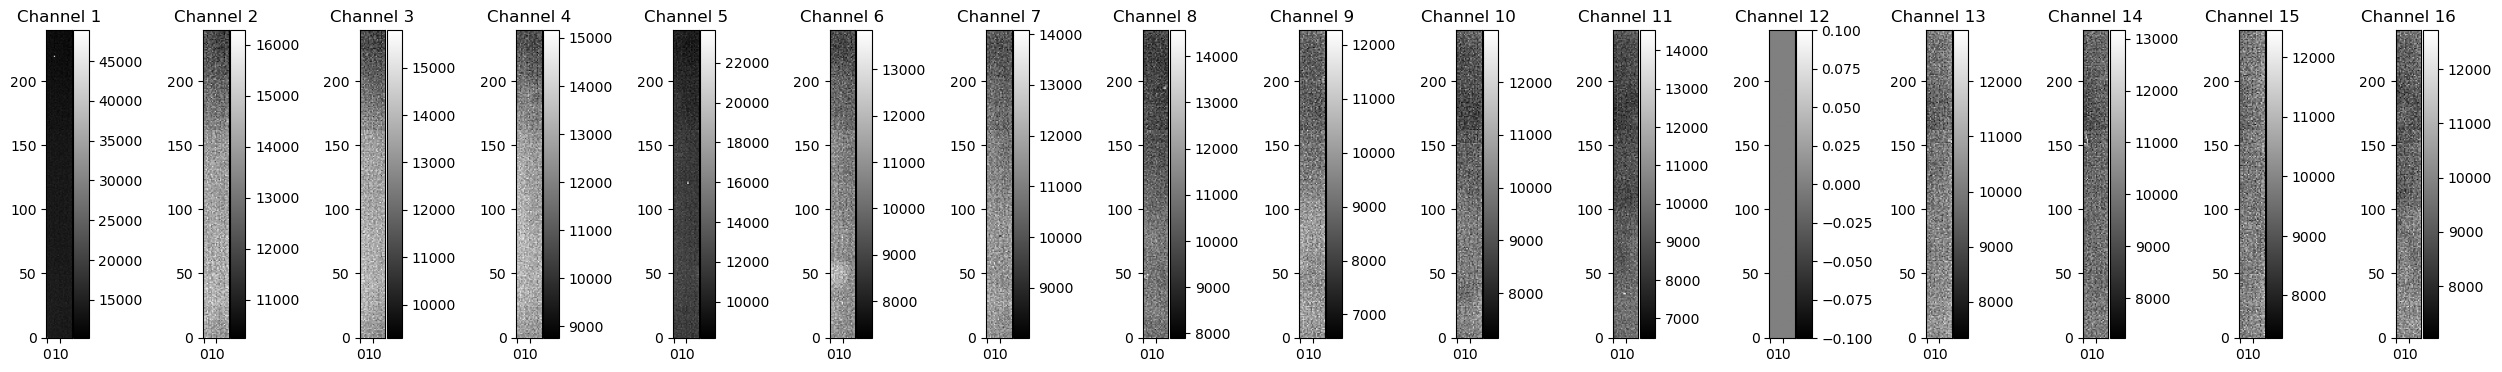

In [17]:
num_channels = 16
channel_data = []

fig, axes = plt.subplots(1, num_channels, figsize=(32, 4))

for i in range(num_channels):
    channel_data.append(data[:, :, i*20:(i+1)*20])
    im = axes[i].imshow(channel_data[i][0], cmap='gray', origin='lower')
    axes[i].set_title("Channel {}".format(i+1))
    plt.colorbar(im, ax=axes[i], pad =0.01)

plt.show()

## First ## Compute $R(f_c)$

### First define an aperture andf compute the measured variance $\sigma^2(f_c)$ within it

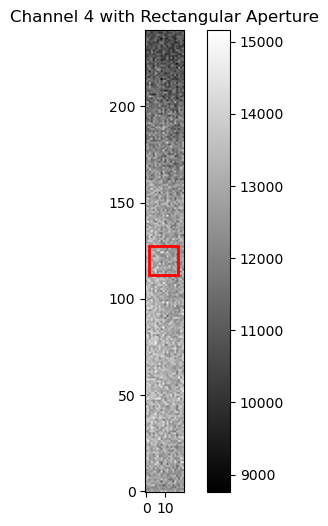

In [18]:
# Take the 4th channel and define a rectangular aperture of radius of size 8 x 8 pixels centered on the middle of the image (no annulus for background subtraction)
channel_4_data = channel_data[3]
aperture = RectangularAperture((9,120), 15, 15) 
# display aperture 
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(channel_4_data[0], cmap='gray', origin='lower')
aperture.plot(color='red', lw=2, ax=ax)
ax.set_title("Channel 4 with Rectangular Aperture")
plt.colorbar(im, ax=ax)
plt.show()  

In [19]:
result = extract_channels(data, channel_width=20, trim=TRIM_FRAMES)

In [20]:
coadds = np.arange(5,300)

In [21]:
ap = RectangularAperture((9, 120), 15, 15)

### PSD calculation for the signals (Welch's Method)

As a first pass at the data, we use the PSD to look for anything telling in the data

In [22]:
psd_freqs, psd_vals = psd_welch(result["channels"], frame_dt_s=0.0103, aperture=ap)

/tmp/ipykernel_449037/3829742711.py:14: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


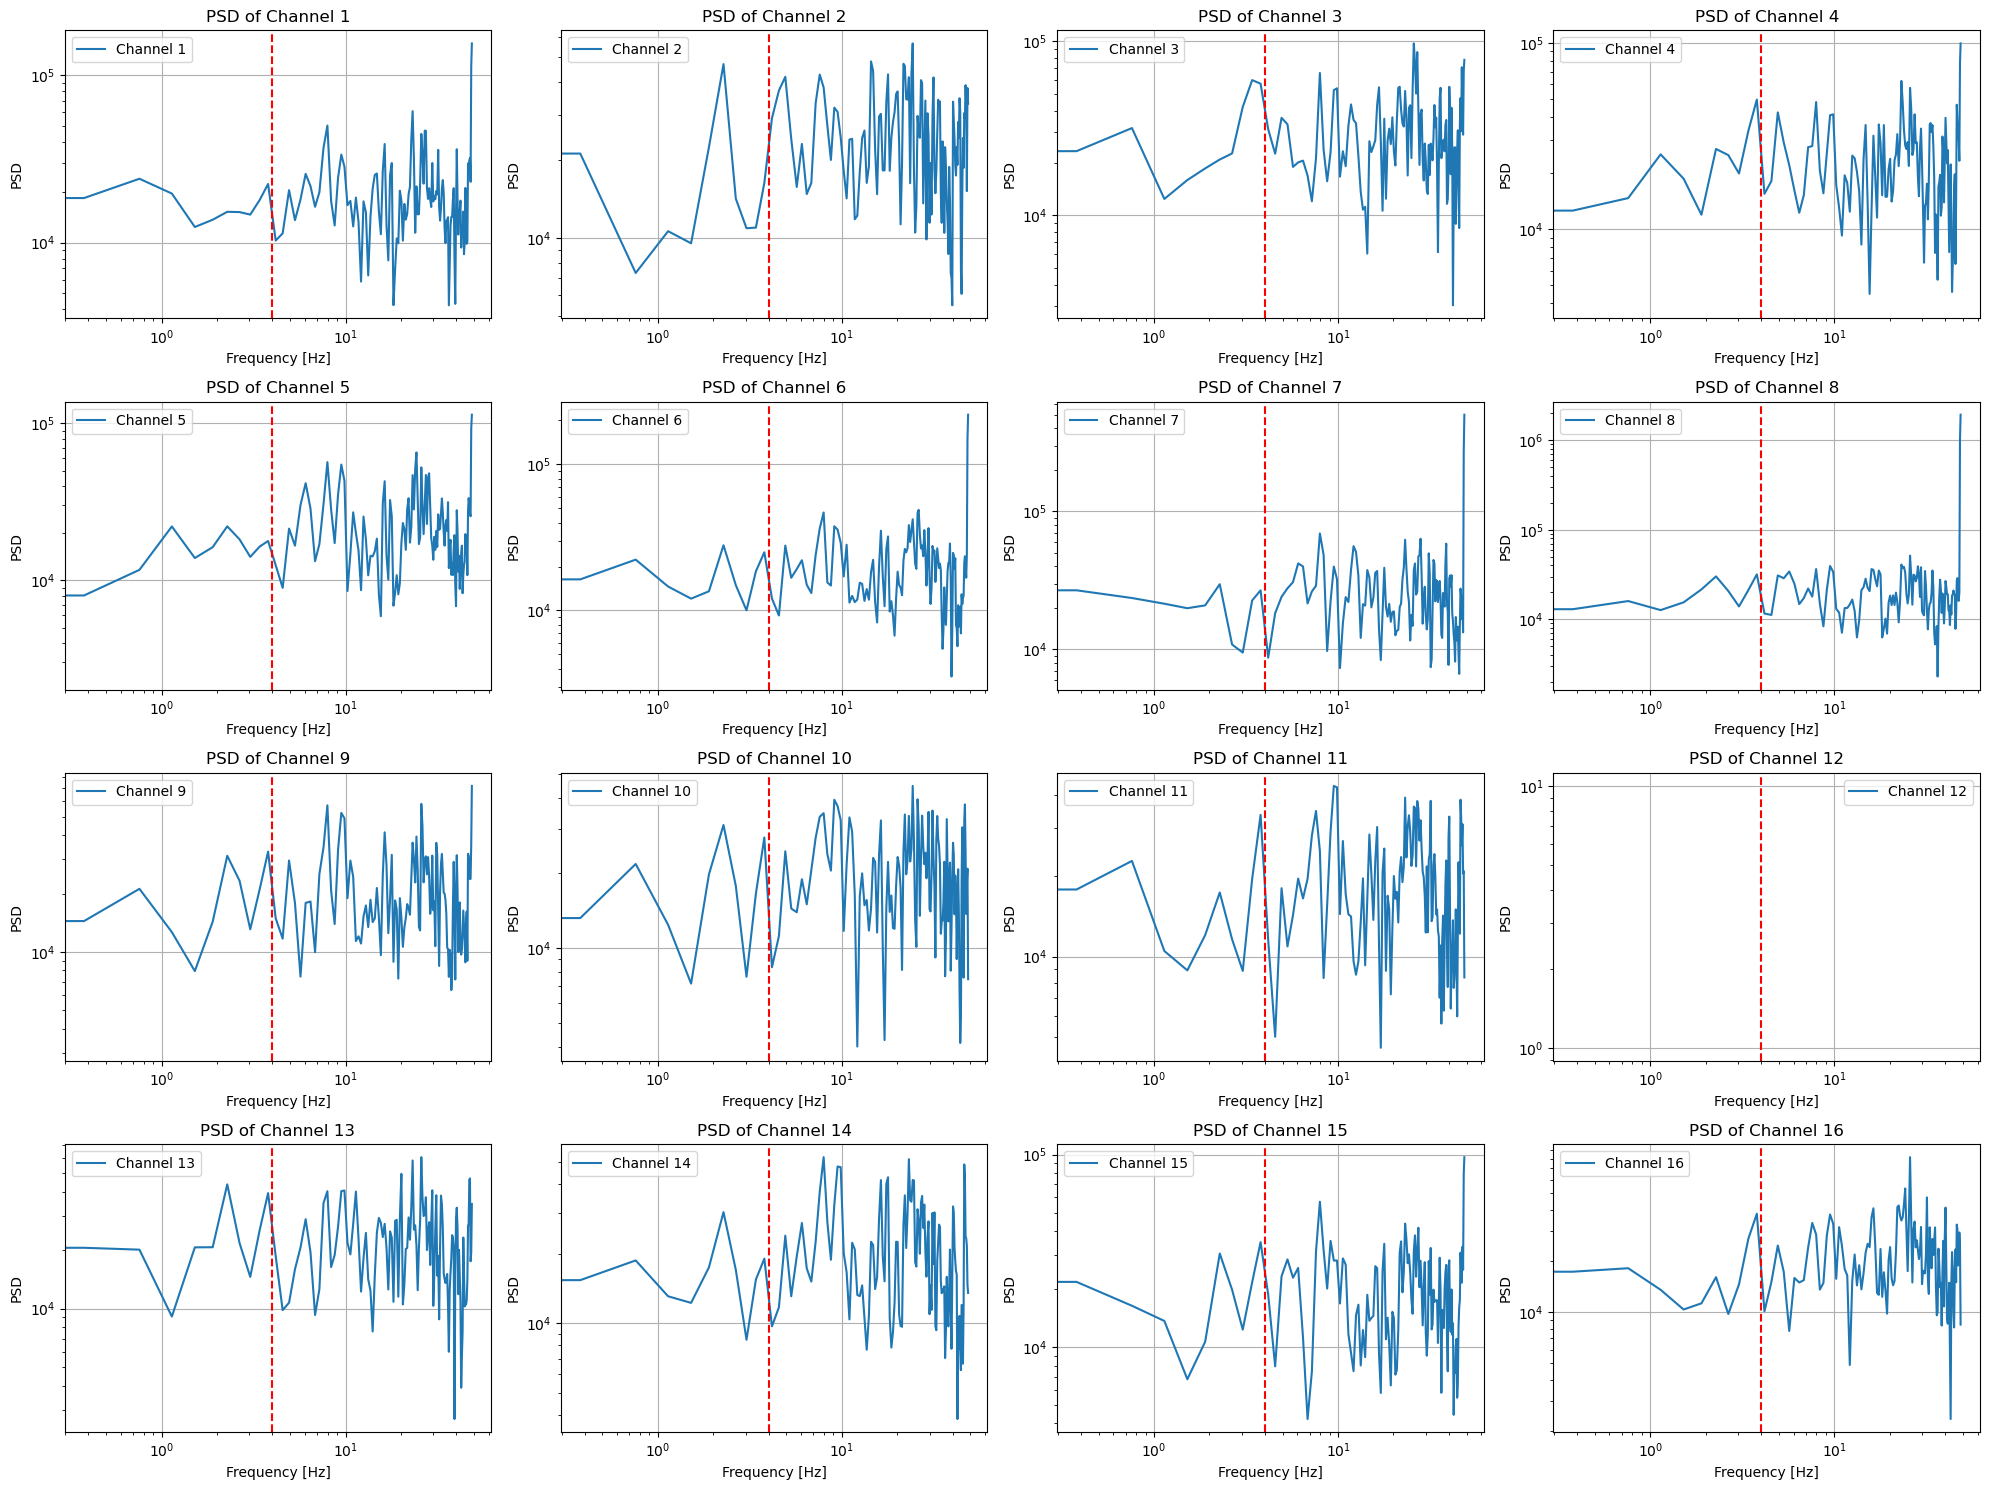

In [23]:
# Plot the psd 
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for i in range(num_channels):
    ax = axes[i//4, i%4]
    freqs = psd_freqs[i]
    psd = psd_vals[i]
    ax.plot(freqs, psd, label=f'Channel {i+1}')
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('PSD')
    ax.set_title(f'PSD of Channel {i+1}')
    ax.grid(True)
    ax.legend()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axvline(4, color='red', linestyle='--', label='Injected Frequency')
plt.tight_layout()
plt.show()

### Build Variance Curves

In [24]:
variances, t_dwell, f_state, f_coadd, = create_variance_curve(result["channels"], coadds_array=coadds, frame_dt_s=0.0103, aperture=ap)


In [32]:
# Build timeseries dictionary for bootstrap analysis
timeseries_by_coadd, meta = build_timeseries_by_coadd(result["channels"], coadds_array=coadds, frame_dt_s=0.0103, aperture=ap)

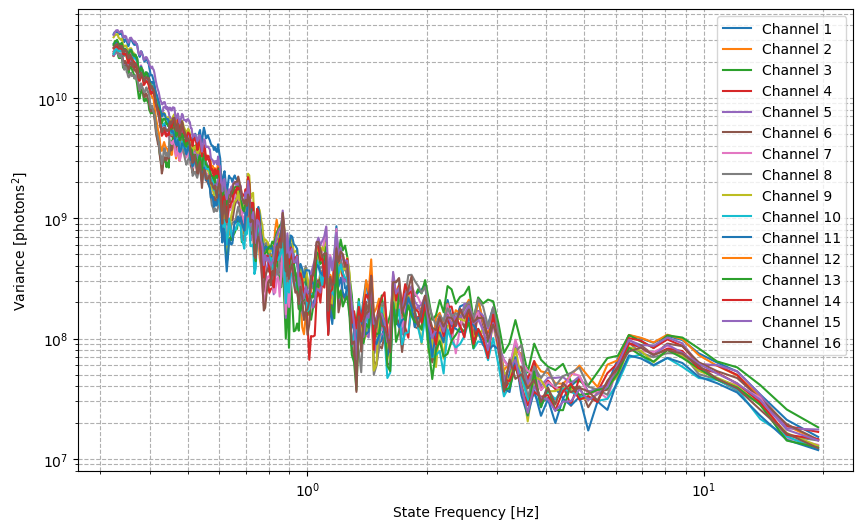

In [25]:
plt.figure(figsize=(10, 6))
for channel in range(result["channels"].shape[0]):  
    channel_variance = [variances[i][channel] for i in range(len(coadds))]
    plt.plot(f_state, channel_variance, label=f'Channel {channel+1}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency [Hz]')
plt.ylabel(r'Variance [photons$^2$]')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

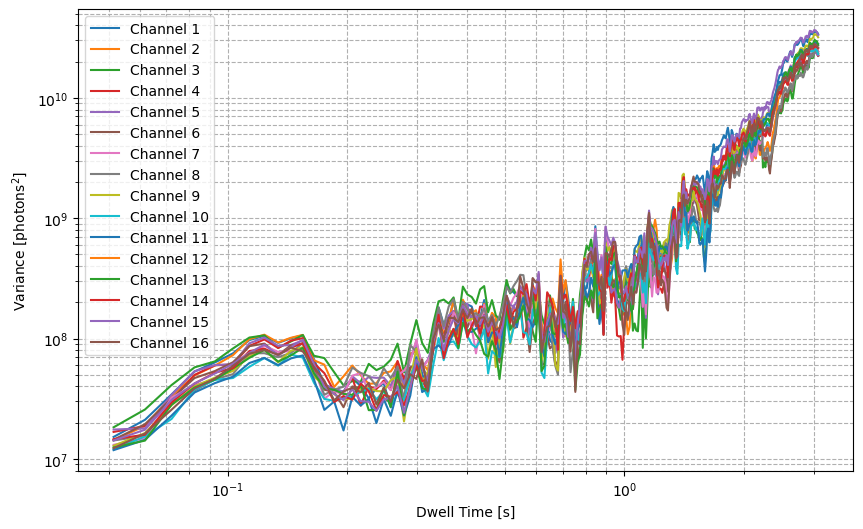

In [26]:
# Plot by dwell time instead 
plt.figure(figsize=(10, 6))
for channel in range(result["channels"].shape[0]):
    channel_variance = [variances[i][channel] for i in range(len(coadds))]
    plt.plot(t_dwell, channel_variance, label=f'Channel {channel+1}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Dwell Time [s]')
plt.ylabel(r'Variance [photons$^2$]')
# plt.title('Variance vs Dwell Time for Each Channel')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Error Estimation on Variance Measurements

We estimate errors on variance measurements using several methods:
1. **Sample count method**: Uses $\sigma(\text{var}) = \text{var} \times \sqrt{2/(N-1)}$ where N is the number of chopped pairs
2. **Bootstrap resampling**: Empirically estimates errors by resampling the data
3. **Channel-to-channel scatter**: Uses standard error across independent channels

In [33]:
errors_by_sample_count = compute_variance_errors_from_sample_count(variances, coadds, n_frames=result["channels"].shape[1])

In [34]:
errors_by_bootstrap = bootstrap_variance_by_coadd(timeseries_by_coadd, n_bootstrap=500)

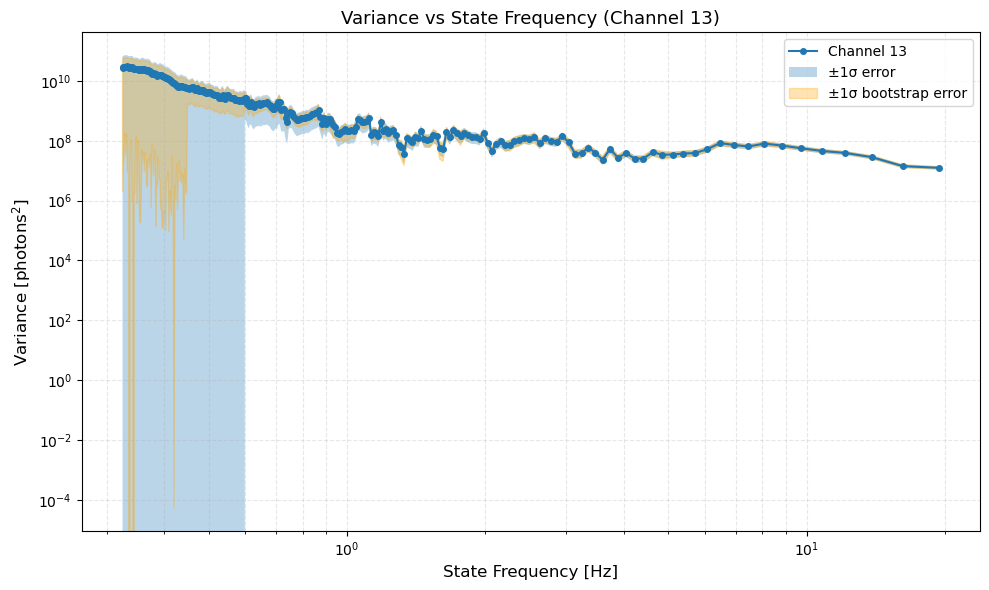

In [ ]:
# Plot the results from just Channel 13 as an example 
# Use fill_between for shaded error region - much cleaner than error bars
channel = 12  # Example: Channel 13

channel_variance = np.array([variances[i][channel] for i in range(len(coadds))])
channel_errors_sample = np.array([errors_by_sample_count[i][channel] for i in range(len(coadds))])
channel_errors_bootstrap = np.array([errors_by_bootstrap[coadds[i]][channel] for i in range(len(coadds))])
f_state_array = np.array(f_state)

plt.figure(figsize=(10, 6))
plt.plot(f_state_array, channel_variance, marker='o', markersize=4, 
         linewidth=1.5, label=f'Channel {channel+1}', zorder=3)
plt.fill_between(f_state_array, 
                 channel_variance - channel_errors_sample, 
                 channel_variance + channel_errors_sample, 
                 alpha=0.3, label='±1σ error')
plt.fill_between(f_state_array, 
                 channel_variance - channel_errors_bootstrap, 
                 channel_variance + channel_errors_bootstrap,
                 alpha=0.3, label='±1σ bootstrap error', color='orange')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('State Frequency [Hz]', fontsize=12)
plt.ylabel(r'Variance [photons$^2$]', fontsize=12)
plt.title(f'Variance vs State Frequency (Channel {channel+1})', fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

It seems like the two methods yield largely the same results. Plot data from every channel to be sure


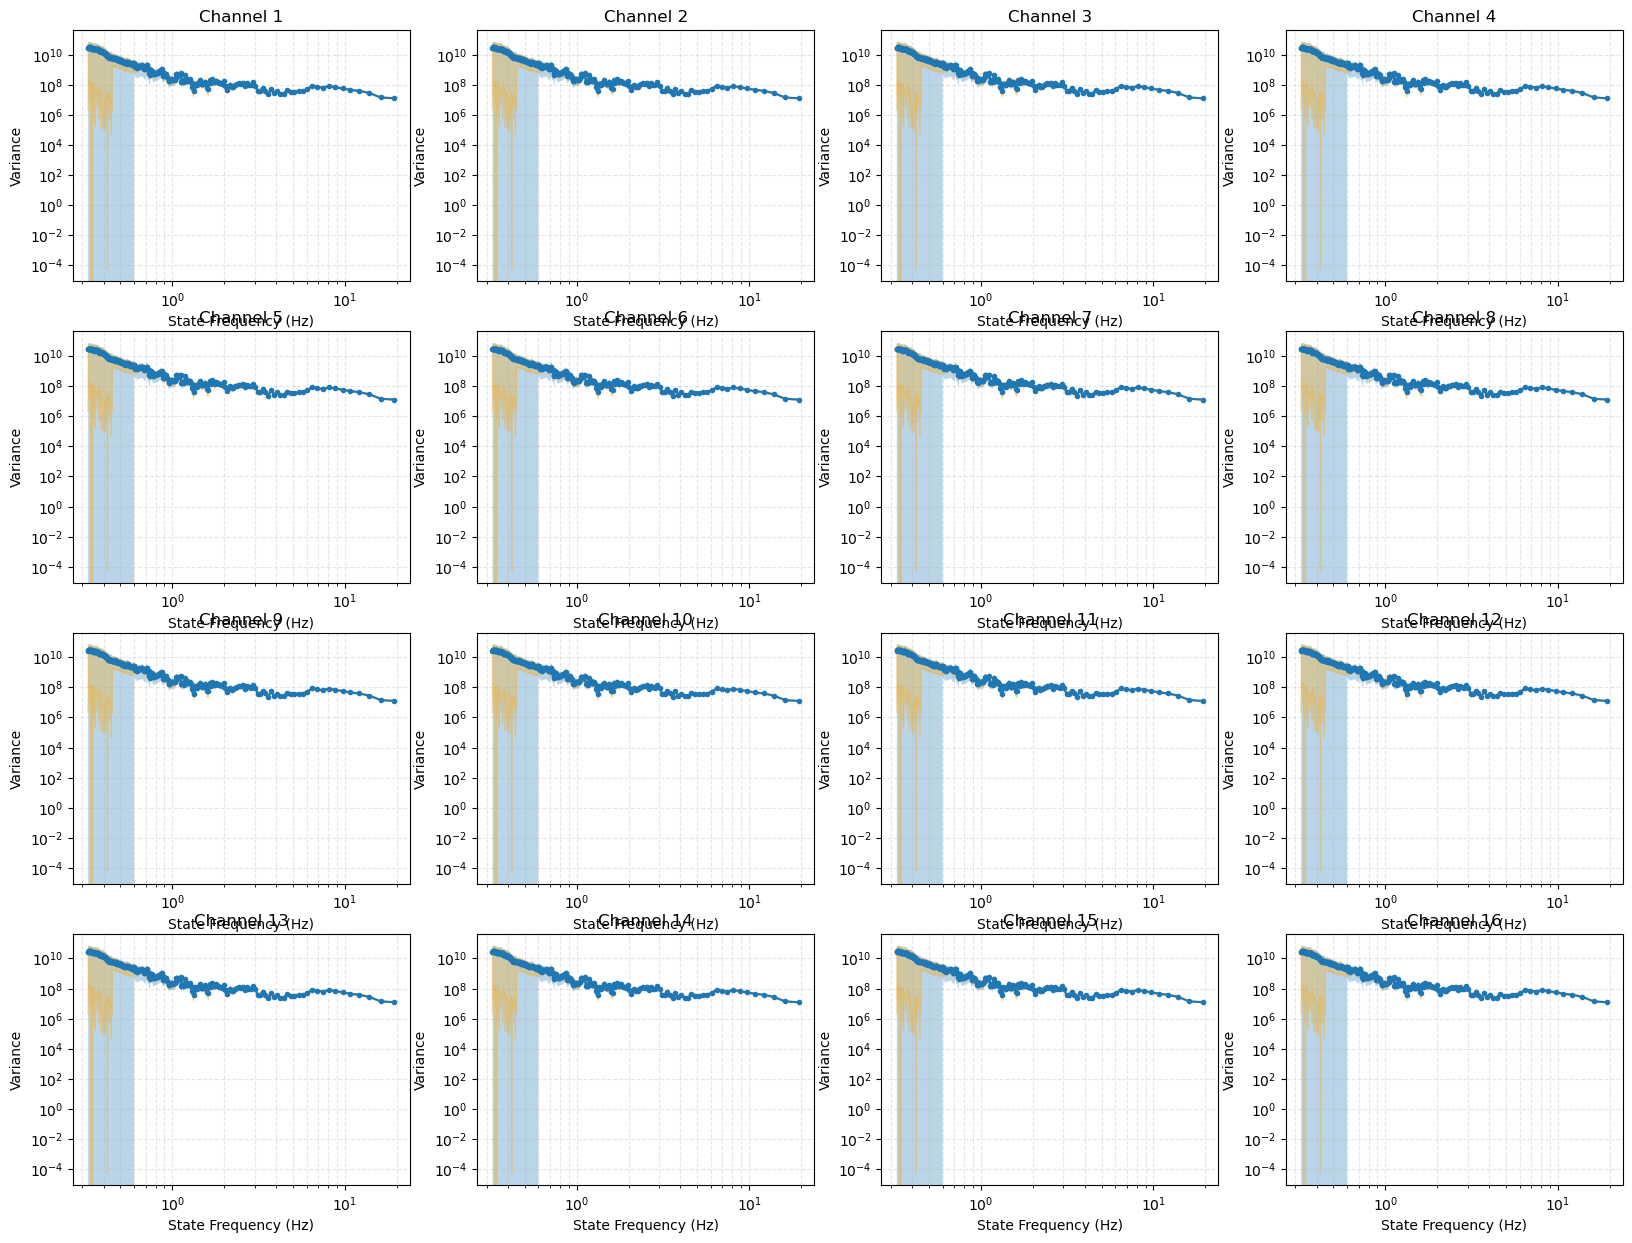

In [39]:
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):  
    ax = axes[channel//4, channel%4]
    
    ax.fill_between(f_state, channel_variance - channel_errors_sample, channel_variance + channel_errors_sample, alpha=0.3)
    ax.fill_between(f_state, channel_variance - channel_errors_bootstrap, channel_variance + channel_errors_bootstrap, alpha=0.3, color='orange')
    ax.plot(f_state, channel_variance, marker='o', markersize=3, linewidth=1.5)
    
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('Variance')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.3)

We can use the bootstrapped error for now as I think that will be better

In [40]:
# Define the frequency of the object - sky subtraction (0.5 Hz)

f_OS = 0.5 
sky_variances_at_f_OS = []

for channel in range(result["channels"].shape[0]):
    ch_variance = [variances[i][channel] for i in range(len(coadds))]

    # np.interp requires x-values in increasing order, but f_state is decreasing
    # So we need to reverse both arrays
    f_state_reversed = np.array(f_state)[::-1]
    ch_variance_reversed = np.array(ch_variance)[::-1]
    
    variance_at_f_OS = np.interp(f_OS, f_state_reversed, ch_variance_reversed)
    sky_variances_at_f_OS.append(variance_at_f_OS)

sky_variances_at_f_OS = np.array(sky_variances_at_f_OS, dtype=float)

/tmp/ipykernel_449037/311154010.py:15: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


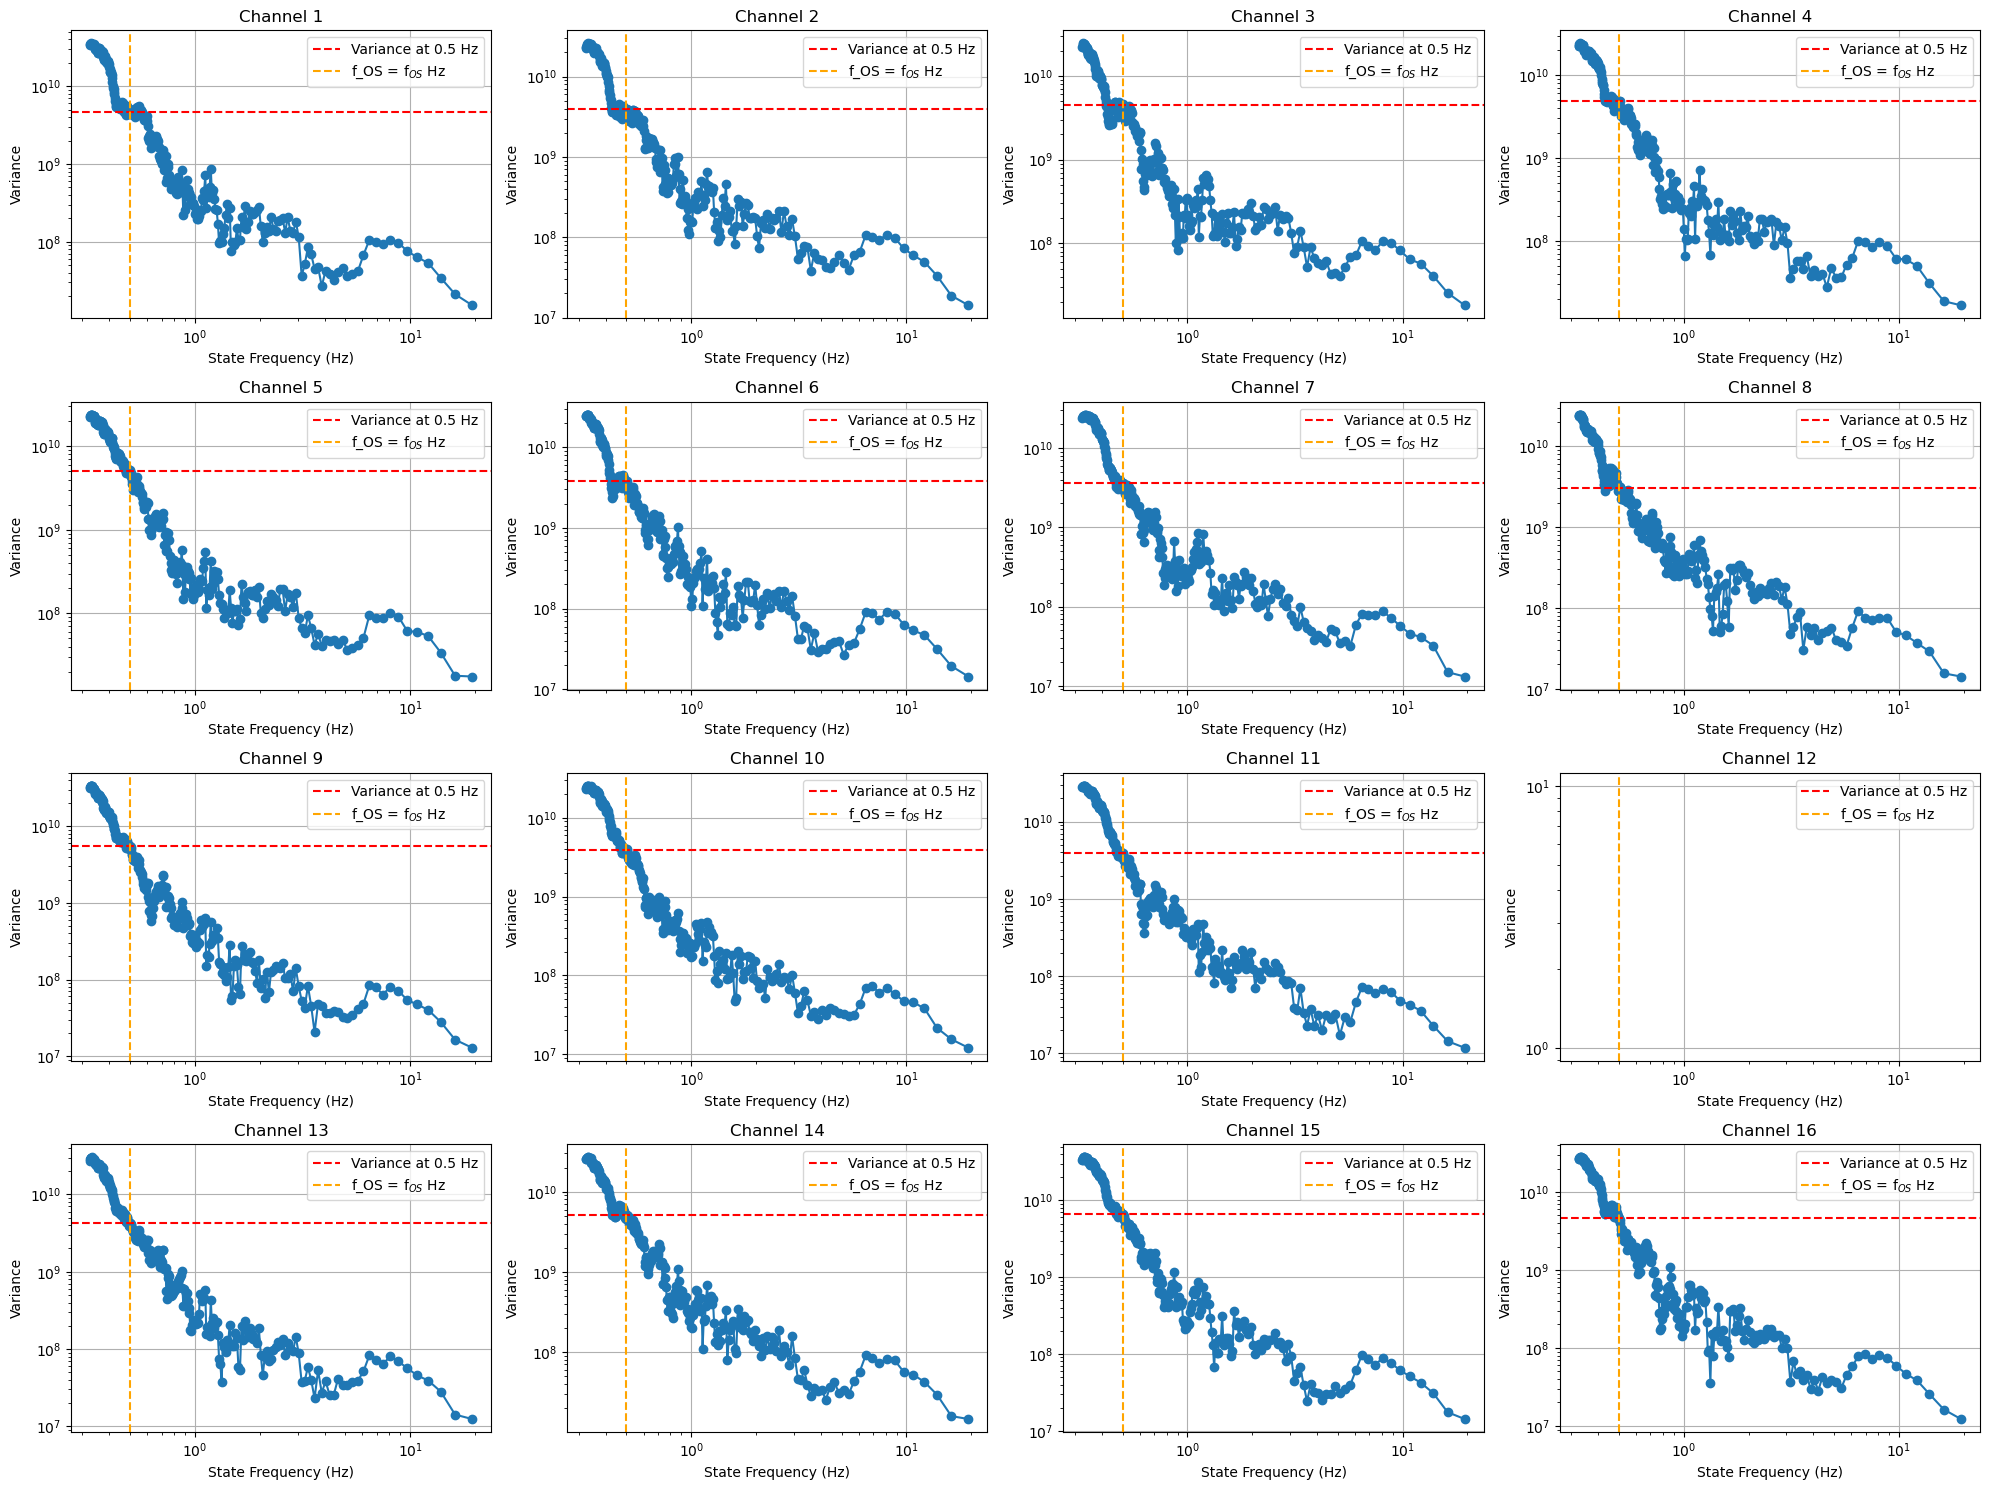

In [41]:
# For each channel, plot the variace curve and mark the variance at f_OS
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    ch_variance = [variances[i][channel] for i in range(len(coadds))]
    ax.plot(f_state, ch_variance, marker='o')
    ax.axhline(sky_variances_at_f_OS[channel], color='red', linestyle='--', label=f'Variance at {f_OS} Hz')
    ax.axvline(f_OS, color='orange', linestyle='--', label=r'f_OS = f$_{OS}$ Hz')
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('Variance')
    ax.grid( True )
    #ax.set_xscale('log')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
plt.tight_layout()
plt.show()

Now, in each channel, divide by the variance at that value to get the normalized variance curve in terms of the "R" parameter.

In [42]:
ch_var_matrix = np.array([[variances[i][channel] for i in range(len(coadds))]
                          for channel in range(result["channels"].shape[0])], dtype=float)
# Safe divide; invalid denominators become NaN
den = sky_variances_at_f_OS[:, None]
R_factor = np.divide(
    ch_var_matrix, den,
    out=np.full_like(ch_var_matrix, np.nan),
    where=np.isfinite(den) & (den > 0)
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


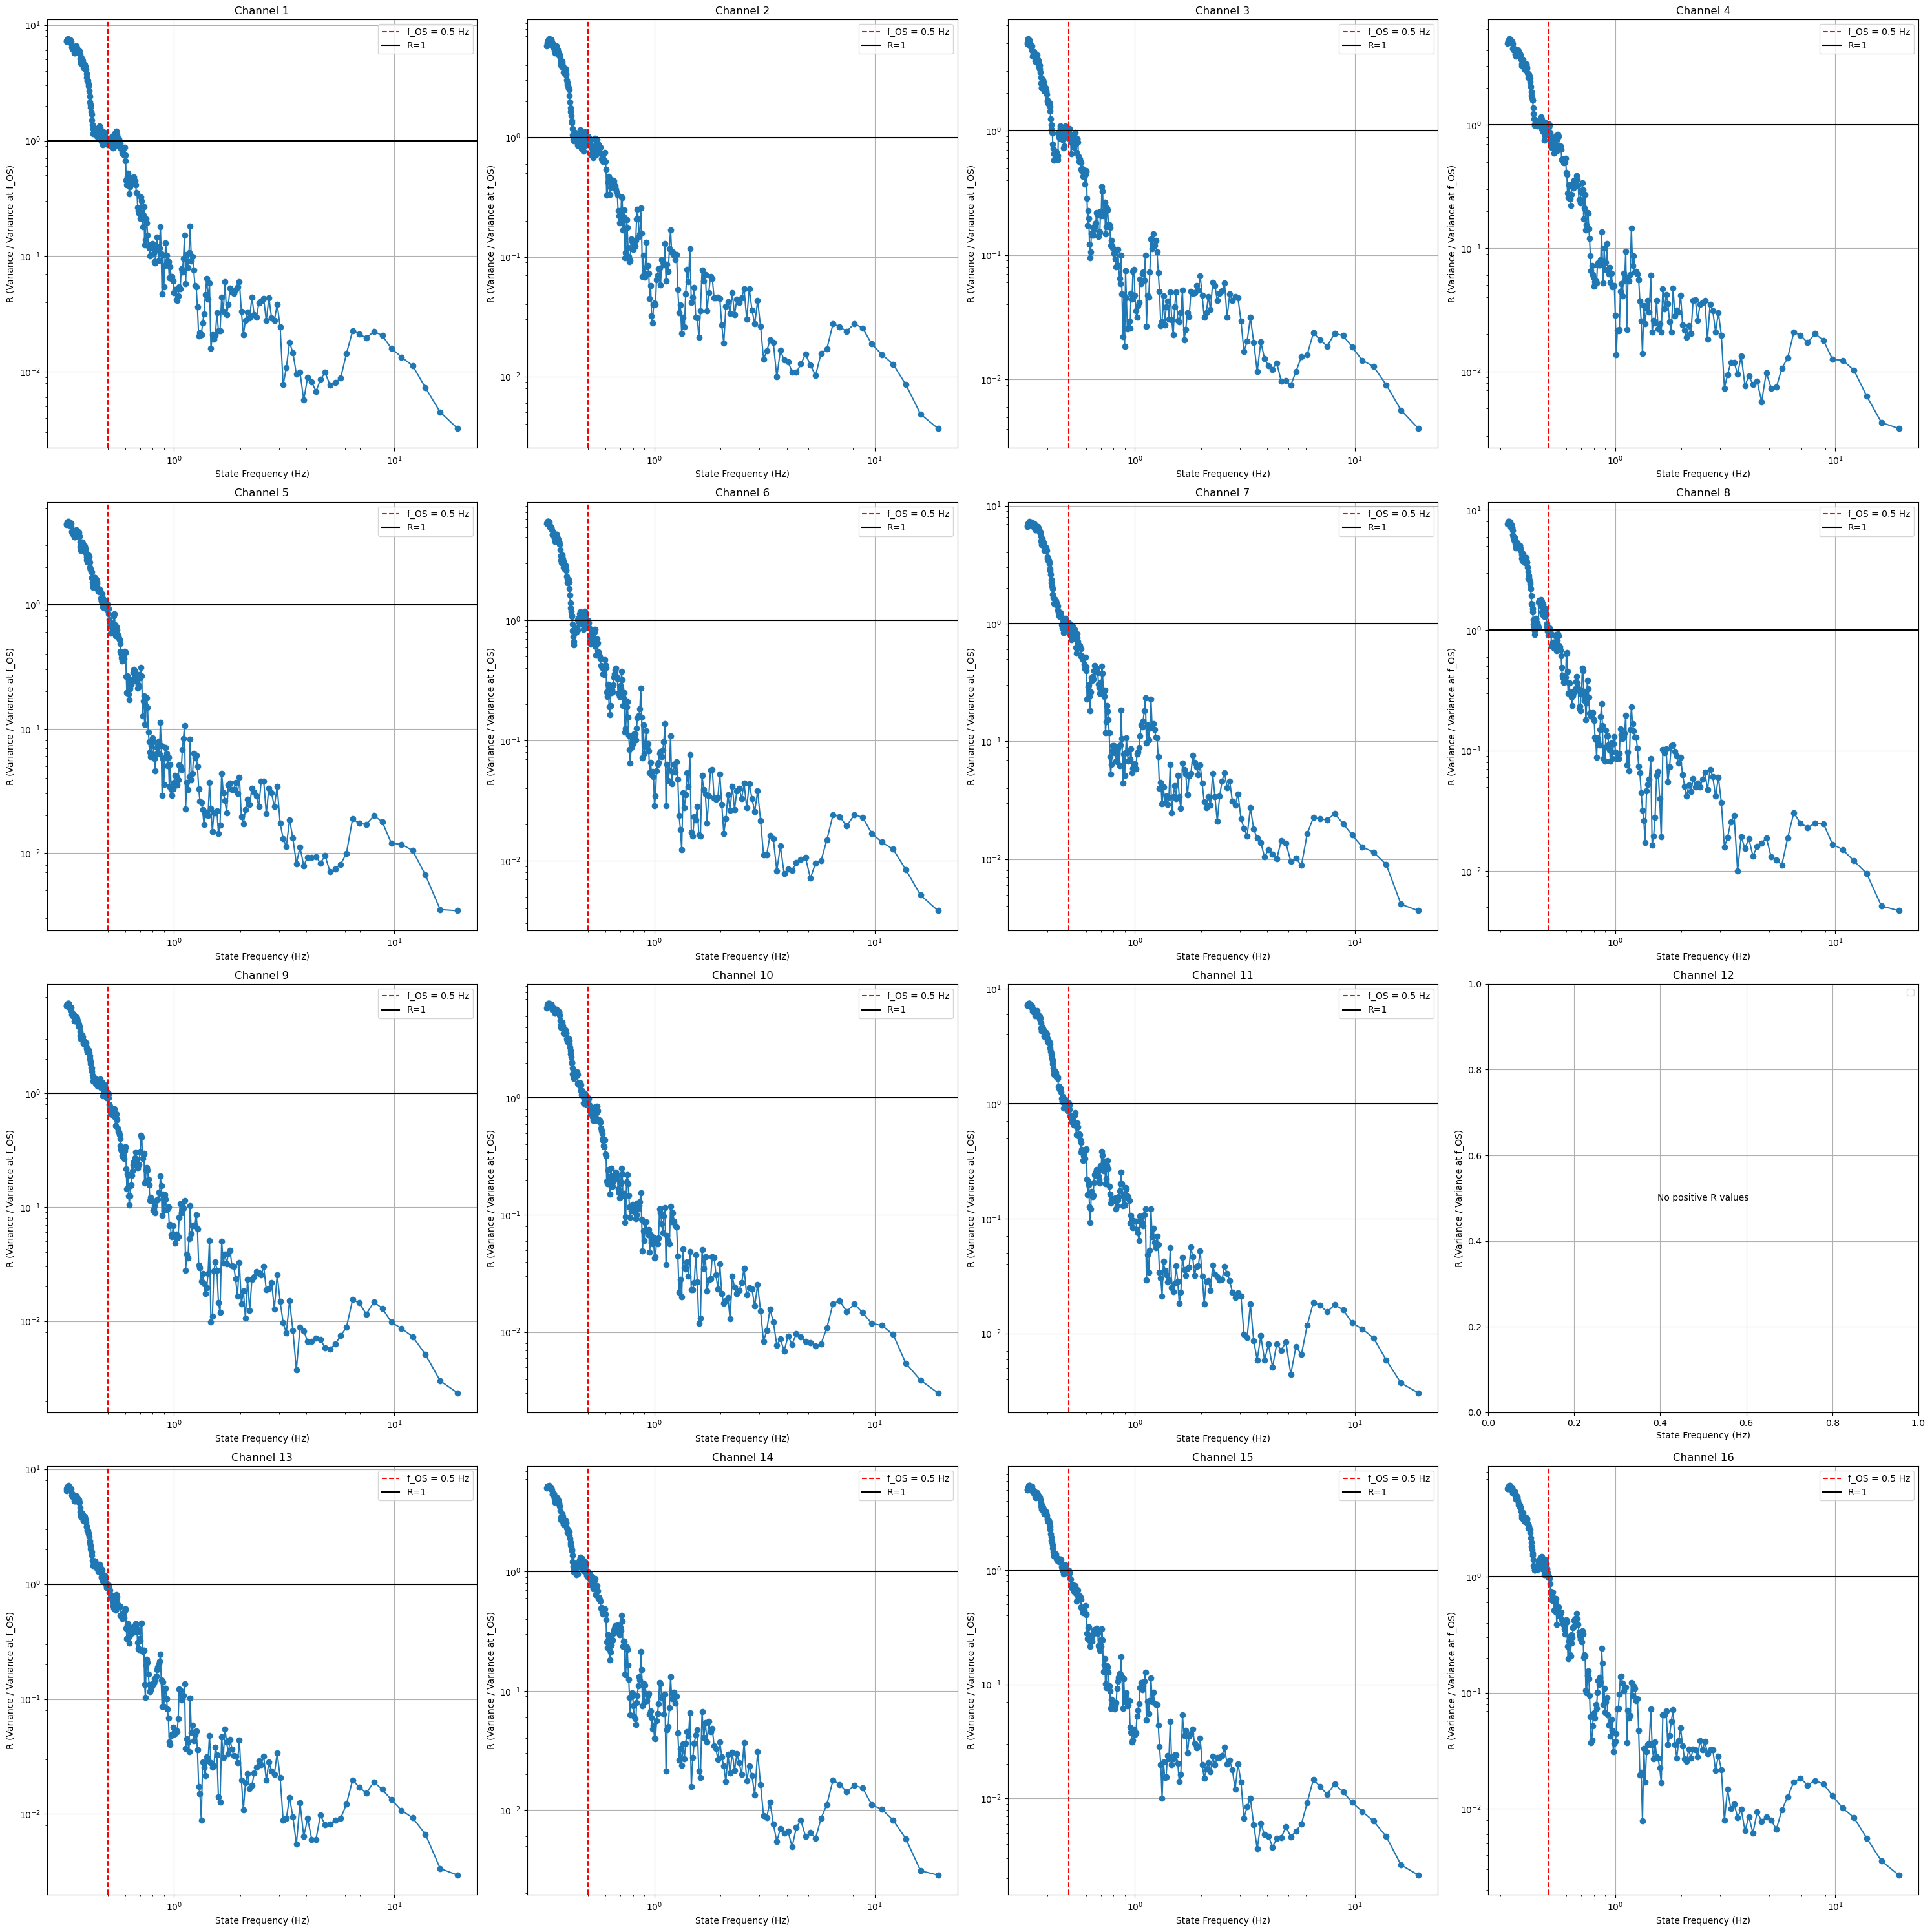

In [46]:
# Double check the shape of the R factor matrix and then plot 
assert R_factor.shape == ch_var_matrix.shape == (16, len(coadds))

# Great, let's repeat the plot but using marking the F_OS point with a vertical dashed line, a black horizontal line ar R = 1, and a red fill (for the entire region) for R > 1 and a light green fill for R < 1 with text that says "no chopping improvment" 
fig, axes = plt.subplots(4, 4, figsize=(30,30))
for channel in range(result["channels"].shape[0]):
    ax = axes[channel // 4, channel % 4]
    R_values = np.array(R_factor[channel], dtype=float)
    xvals = np.array(f_state, dtype=float)

    # Log scale requires strictly positive finite values
    good = np.isfinite(R_values) & (R_values > 0) & np.isfinite(xvals) & (xvals > 0)

    if np.any(good):
        ax.plot(xvals[good], R_values[good], marker='o')
        ax.set_xscale('log')
        ax.set_yscale('log')

        # Add vertical line at f_OS
        ax.axvline(f_OS, color='red', linestyle='--', label=f'f_OS = {f_OS} Hz')

        # Add horizontal line at R=1
        ax.axhline(1, color='black', linestyle='-', label='R=1')

    else:
        ax.text(0.5, 0.5, "No positive R values", ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'Channel {channel+1}')
    ax.set_xlabel('State Frequency (Hz)')
    ax.set_ylabel('R (Variance / Variance at f_OS)')
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()
